# Notebook 2: Binary Mask Generation (Built-Up vs. Other)

**Goal:** Create perfectly aligned semantic segmentation masks to pair with our previously downloaded SWISSIMAGE crops. We will:
1. Load the spatial anchors (building centroids and splits) generated in Notebook 1.
2. Load and preprocess the raw Biotope Mapping data (BTK 2020) from the City of Zürich.
3. Map the granular biotope classes to a binary scheme: Built-up (Class 13) vs. Other.
4. For every building anchor, dynamically crop the intersecting biotope polygons.
5. Rasterize these vector polygons into `512x512` pixel arrays to exactly match the dimensions and spatial resolution of our SWISSIMAGE tensors.
6. Save the masks to the appropriate `train` and `val` directories.

In [2]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio import features
from rasterio.transform import from_bounds
from tqdm.auto import tqdm
import warnings

# Suppress geometry warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Setup Directories & Load Building Anchors
First, we ensure our output directories exist for this specific segmentation task (`masks_builtup`). Then, we load the `.gpkg` file we created in Notebook 1, which holds the coordinates and unique IDs for all our sampled buildings.

In [3]:
# --- Configuration ---
BASE_OUT = "../data/processed_modular"
MASK_TASK_DIR = "masks_builtup"
META_DIR = f"{BASE_OUT}/metadata"

# Find the metadata file from Notebook 1 (assuming it's the only gpkg in the folder or name it explicitly)
# Update this filename if you used a different sample size!
ANCHORS_FILE = f"{META_DIR}/building_anchors_20.gpkg" 

for split in ['train', 'val']:
    os.makedirs(f"{BASE_OUT}/{split}/{MASK_TASK_DIR}", exist_ok=True)

print(f"Loading spatial anchors from: {ANCHORS_FILE}")
gdf_anchors = gpd.read_file(ANCHORS_FILE)
print(f"Loaded {len(gdf_anchors)} building anchors.")

Loading spatial anchors from: ../data/processed_modular/metadata/building_anchors_20.gpkg
Loaded 20 building anchors.


## 2. Load and Prepare Biotope Data
Here we execute the data preparation logic. We read the raw shapefile, inspect the area statistics for the highest-level superclass (`lrtyp1code`), and map class `"13"` (which represents built-up/sealed surfaces) to `1`, while all other classes become `0`.

In [4]:
# --- Load Raw Biotope Data ---
BIOTOPE_PATH = "/Users/fadricampell/Documents/HSLU/Modules/rBootcamp/r-bootcamp/data/biotoptypen2020/data/gsz.btk_2020.shp"
print("Loading raw biotope shapefile...")
gdf_biotope = gpd.read_file(BIOTOPE_PATH)

# Ensure the CRS matches our metric Swiss coordinates (EPSG:2056)
if gdf_biotope.crs.to_string() != 'EPSG:2056':
    gdf_biotope = gdf_biotope.to_crs(epsg=2056)

# Select target columns
class_id = 'lrtyp1code'
class_name = 'lrtyp1text'

# Calculate areas and stats
gdf_biotope['area_sqm'] = gdf_biotope.geometry.area
class_stats = gdf_biotope.groupby([class_id, class_name]).agg(
    total_area_sqm=('area_sqm', 'sum'),
    polygon_count=('geometry', 'count')
).reset_index()
class_stats = class_stats.sort_values(by='total_area_sqm', ascending=False)

print("\n--- Biotope Class Statistics ---")
for i in range(len(class_stats)):
    print(f"ID: {class_stats.iloc[i][class_id]} | Name: {class_stats.iloc[i][class_name]} | Area: {class_stats.iloc[i]['total_area_sqm']:.0f} sqm")

# Create the binary label directly in the GeoDataFrame (1 for Built-up, 0 for Other)
gdf_binary = gdf_biotope.copy()
gdf_binary['builtup'] = gdf_biotope[class_id].apply(lambda x: 1 if str(x) == "13" else 0)

print("\n--- Binary Mask Distribution (Polygon Count) ---")
print(gdf_binary['builtup'].value_counts())

Loading raw biotope shapefile...

--- Biotope Class Statistics ---
ID: 13 | Name: Gebäude-, Verkehrs- und Industrieflächen | Area: 30593125 sqm
ID: 12 | Name: Siedlungen | Area: 22488728 sqm
ID: 01 | Name: Wälder | Area: 21405080 sqm
ID: 09 | Name: Grünland | Area: 5706527 sqm
ID: 04 | Name: Gewässer | Area: 5191474 sqm
ID: 10 | Name: Acker- und Gartenbau-Biotope | Area: 3314411 sqm
ID: 11 | Name: Ruderalfluren | Area: 1613056 sqm
ID: 02 | Name: Gebüsche und Gehölzbestände | Area: 1173414 sqm
ID: 05 | Name: Gehölzfreie Biotope der Sümpfe, Flachmoore und Ufer | Area: 280246 sqm
ID: 08 | Name: Magerrasen | Area: 115005 sqm

--- Binary Mask Distribution (Polygon Count) ---
builtup
0    50520
1    45658
Name: count, dtype: int64


## 3. Crop and Rasterize Masks
We now loop through our building anchors. For each building, we define a 100x100m bounding box. We isolate the biotope polygons that intersect this box, and use `rasterio.features.rasterize` to "burn" these vector polygons into a `512x512` pixel grid. 

*Note: If a bounding box happens to have no intersecting polygons (e.g., right on the border of the dataset), it will naturally default to an array of zeros.*

In [6]:
# Spatial parameters to match the images from Notebook 1
CROP_RADIUS_M = 50 
IMG_SIZE = 512

successful = 0
empty_masks = 0

print(f"Generating binary masks for {len(gdf_anchors)} locations...")

for idx, row in tqdm(gdf_anchors.iterrows(), total=len(gdf_anchors)):
    uid = row['unique_id']
    split = row['split']
    cx = row['x_2056']
    cy = row['y_2056']
    
    out_path = f"{BASE_OUT}/{split}/{MASK_TASK_DIR}/{uid}_mask.tif"
    
    # Skip if mask already exists
    if os.path.exists(out_path):
        successful += 1
        continue
    
    # Define exact bounding box metrics
    minx, maxx = cx - CROP_RADIUS_M, cx + CROP_RADIUS_M
    miny, maxy = cy - CROP_RADIUS_M, cy + CROP_RADIUS_M
    
    # 1. Spatial Subset: Grab only polygons intersecting our bounding box
    intersecting_polys = gdf_binary.cx[minx:maxx, miny:maxy]
    
    # Create the transform to map 100m of physical space into a 512x512 grid
    transform = from_bounds(minx, miny, maxx, maxy, IMG_SIZE, IMG_SIZE)
    
    # 2. Rasterize
    if len(intersecting_polys) > 0:
        # Create an iterable of (geometry, value) pairs
        shapes = ((geom, val) for geom, val in zip(intersecting_polys.geometry, intersecting_polys['builtup']))
        
        mask = features.rasterize(
            shapes=shapes,
            out_shape=(IMG_SIZE, IMG_SIZE),
            transform=transform,
            fill=0,               # Background becomes 0 (Other)
            dtype=rasterio.uint8  # 8-bit unsigned integer is standard for masks
        )
    else:
        # If no polygons intersect, the entire mask is "Other" (0)
        mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=rasterio.uint8)
        empty_masks += 1

    # 3. Save as a single-band GeoTIFF
    out_meta = {
        'driver': 'GTiff',
        'height': IMG_SIZE,
        'width': IMG_SIZE,
        'count': 1,
        'dtype': rasterio.uint8,
        'crs': 'EPSG:2056',
        'transform': transform,
        'compress': 'lzw' # Lightweight compression for masks
    }
    
    with rasterio.open(out_path, 'w', **out_meta) as dest:
        dest.write(mask, 1)
        
    successful += 1

print(f"\n✅ Mask generation complete!")
print(f"Total processed: {successful}")
print(f"Masks strictly containing '0' due to no dataset coverage: {empty_masks}")

Generating binary masks for 20 locations...


  0%|          | 0/20 [00:00<?, ?it/s]


✅ Mask generation complete!
Total processed: 20
Masks strictly containing '0' due to no dataset coverage: 0


## 4. Sanity Check: Visualize an Image-Mask Pair
To ensure our coordinate transforms worked perfectly, let's load one random image from Notebook 1 and its corresponding mask generated here, and overlay them.

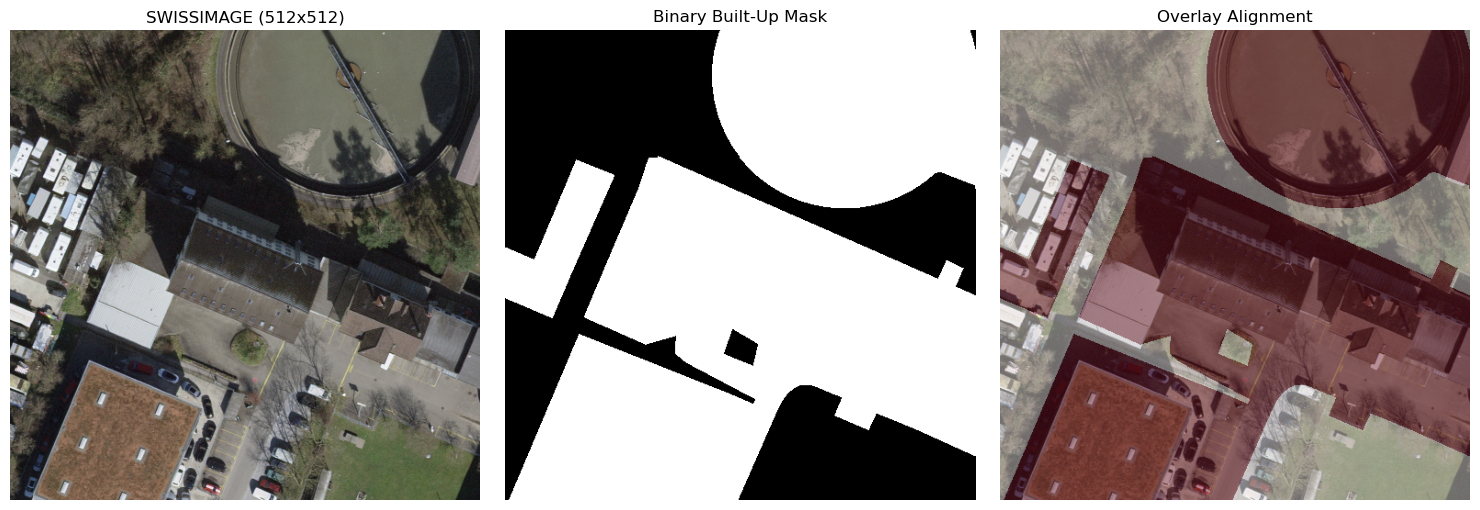

In [7]:
# Grab a random anchor from the training set
sample_row = gdf_anchors[gdf_anchors['split'] == 'train'].sample(1).iloc[0]
uid = sample_row['unique_id']

img_path = f"{BASE_OUT}/train/images/{uid}_swissimage.tif"
mask_path = f"{BASE_OUT}/train/{MASK_TASK_DIR}/{uid}_mask.tif"

if os.path.exists(img_path) and os.path.exists(mask_path):
    with rasterio.open(img_path) as src_img:
        # Swisstopo might return 3 (RGB) or 4 (RGBA) channels
        img = src_img.read()[:3] 
        # Convert from (C, H, W) to (H, W, C) for matplotlib
        img = np.moveaxis(img, 0, -1) 
        
    with rasterio.open(mask_path) as src_mask:
        mask = src_mask.read(1)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    
    axs[0].imshow(img)
    axs[0].set_title("SWISSIMAGE (512x512)")
    axs[0].axis("off")
    
    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Binary Built-Up Mask")
    axs[1].axis("off")
    
    # Overlay
    axs[2].imshow(img)
    axs[2].imshow(mask, cmap="Reds", alpha=0.4) # Overlay mask in semi-transparent red
    axs[2].set_title("Overlay Alignment")
    axs[2].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Could not find both files for UID: {uid}. Ensure Notebook 1 ran successfully.")